In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyexpat import features

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
pd.options.display.max_columns = 60
pd.options.display.max_colwidth = 500

In [4]:
data_business = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_business.json', lines=True)

data_checkin = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_checkin.json', lines=True)

data_photo = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_photo.json', lines=True)

data_review = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_review.json', lines=True)

data_tip = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_tip.json', lines=True)

data_user = pd.read_json(r'C:\Users\vorob\PycharmProjects\RestaurantsReveiw\data\yelp_user.json', lines=True)

In [5]:
data_business.head()

,address,alcohol?,attributes,business_id,categories,city,good_for_kids,has_bike_parking,has_wifi,hours,is_open,latitude,longitude,name,neighborhood,postal_code,price_range,review_count,stars,state,take_reservations,takes_credit_cards
0,1314 44 Avenue NE,0,"{'BikeParking': 'False', 'BusinessAcceptsCreditCards': 'True', 'BusinessParking': '{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}', 'GoodForKids': 'True', 'HasTV': 'True', 'NoiseLevel': 'average', 'OutdoorSeating': 'False', 'RestaurantsAttire': 'casual', 'RestaurantsDelivery': 'False', 'RestaurantsGoodForGroups': 'True', 'RestaurantsPriceRange2': '2', 'RestaurantsReservations': 'True', 'RestaurantsTakeOut': 'True'}",Apn5Q_b6Nz61Tq4XzPdf9A,"Tours, Breweries, Pizza, Restaurants, Food, Hotels & Travel",Calgary,1,0,0,"{'Monday': '8:30-17:0', 'Tuesday': '11:0-21:0', 'Wednesday': '11:0-21:0', 'Thursday': '11:0-21:0', 'Friday': '11:0-21:0', 'Saturday': '11:0-21:0'}",1,51.091813,-114.031675,Minhas Micro Brewery,,T2E 6L6,2,24,4.0,AB,1,1
1,,0,"{'Alcohol': 'none', 'BikeParking': 'False', 'BusinessAcceptsCreditCards': 'True', 'BusinessParking': '{'garage': False, 'street': True, 'validated': False, 'lot': True, 'valet': False}', 'Caters': 'True', 'DogsAllowed': 'True', 'DriveThru': 'False', 'GoodForKids': 'True', 'GoodForMeal': '{'dessert': False, 'latenight': False, 'lunch': False, 'dinner': False, 'breakfast': False, 'brunch': False}', 'HasTV': 'False', 'OutdoorSeating': 'True', 'RestaurantsAttire': 'casual', 'RestaurantsDelivery'...",AjEbIBw6ZFfln7ePHha9PA,"Chicken Wings, Burgers, Caterers, Street Vendors, Barbeque, Food Trucks, Food, Restaurants, Event Planning & Services",Henderson,1,0,0,"{'Friday': '17:0-23:0', 'Saturday': '17:0-23:0', 'Sunday': '17:0-23:0'}",0,35.960734,-114.939821,CK'S BBQ & Catering,,89002,2,3,4.5,NV,0,1
2,1335 rue Beaubien E,1,"{'Alcohol': 'beer_and_wine', 'Ambience': '{'romantic': False, 'intimate': False, 'classy': False, 'hipster': False, 'touristy': False, 'trendy': False, 'upscale': False, 'casual': False}', 'BikeParking': 'True', 'BusinessAcceptsCreditCards': 'False', 'BusinessParking': '{'garage': False, 'street': False, 'validated': False, 'lot': False, 'valet': False}', 'Caters': 'False', 'GoodForKids': 'True', 'GoodForMeal': '{'dessert': False, 'latenight': False, 'lunch': False, 'dinner': False, 'breakfa...",O8S5hYJ1SMc8fA4QBtVujA,"Breakfast & Brunch, Restaurants, French, Sandwiches, Cafes",Montréal,1,1,1,"{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0', 'Wednesday': '10:0-22:0', 'Thursday': '10:0-22:0', 'Friday': '10:0-22:0', 'Saturday': '10:0-22:0', 'Sunday': '10:0-22:0'}",0,45.540503,-73.599300,La Bastringue,Rosemont-La Petite-Patrie,H2G 1K7,2,5,4.0,QC,1,0
3,211 W Monroe St,0,None,bFzdJJ3wp3PZssNEsyU23g,"Insurance, Financial Services",Phoenix,0,0,0,None,1,33.449999,-112.076979,Geico Insurance,,85003,0,8,1.5,AZ,0,0
4,2005 Alyth Place SE,0,{'BusinessAcceptsCreditCards': 'True'},8USyCYqpScwiNEb58Bt6CA,"Home & Garden, Nurseries & Gardening, Shopping, Local Services, Automotive, Electronics Repair",Calgary,0,0,0,"{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', 'Wednesday': '8:0-17:0', 'Thursday': '8:0-17:0', 'Friday': '8:0-17:0'}",1,51.035591,-114.027366,Action Engine,,T2H 0N5,0,4,2.0,AB,0,1


In [6]:
data_review.head()

,business_id,average_review_age,average_review_length,average_review_sentiment,number_funny_votes,number_cool_votes,number_useful_votes
0,--1UhMGODdWsrMastO9DZw,524.458333,466.208333,0.808638,1,16,15
1,--6MefnULPED_I942VcFNA,1199.589744,785.205128,0.669126,27,32,53
2,--7zmmkVg-IMGaXbuVd0SQ,717.851852,536.592593,0.820837,29,52,81
3,--8LPVSo5i0Oo61X01sV9A,751.750000,478.250000,0.170925,0,0,9
4,--9QQLMTbFzLJ_oT-ON3Xw,978.727273,436.181818,0.562264,3,4,7


Можно смерджить все датасеты в один по полю `business_id`

In [7]:
df = pd.merge(data_business, data_review, how='left', on='business_id')
df = pd.merge(df, data_checkin, how='left', on='business_id')
df = pd.merge(df, data_tip, how='left', on='business_id')
df = pd.merge(df, data_user, how='left', on='business_id')
df = pd.merge(df, data_photo, how='left', on='business_id')
df.shape

(188593, 40)

Удалим все не непрерывные колонки, так как для построение модели линейной регрессии признаки должны быть непрерывны

In [8]:
features_to_remove = ['address', 'attributes', 'business_id', 'categories', 'city', 'hours', 'is_open', 'latitude', 'longitude', 'name', 'neighborhood', 'postal_code', 'state', 'time']

In [9]:
df.drop(features_to_remove, axis=1, inplace=True)

In [10]:
df.head()

,alcohol?,good_for_kids,has_bike_parking,has_wifi,price_range,review_count,stars,take_reservations,takes_credit_cards,average_review_age,average_review_length,average_review_sentiment,number_funny_votes,number_cool_votes,number_useful_votes,weekday_checkins,weekend_checkins,average_tip_length,number_tips,average_number_friends,average_days_on_yelp,average_number_fans,average_review_count,average_number_years_elite,average_caption_length,number_pics
0,0,1,0,0,2,24,4.0,1,1,618.250000,532.916667,0.865342,6,5,13,11.0,18.0,38.0,6.0,42.833333,1809.375000,5.375000,114.875000,1.125000,NaN,NaN
1,0,1,0,0,2,3,4.5,0,1,371.666667,481.333333,0.975000,0,1,1,0.0,1.0,66.0,1.0,64.333333,970.333333,2.666667,19.666667,0.666667,29.0,1.0
2,1,1,1,1,2,5,4.0,1,0,1106.200000,252.000000,0.301240,0,2,1,2.0,5.0,32.0,1.0,4.200000,1499.600000,1.000000,24.600000,0.600000,NaN,NaN
3,0,0,0,0,0,8,1.5,0,0,398.500000,672.625000,-0.060500,1,0,3,1.0,0.0,NaN,NaN,12.500000,1626.500000,2.375000,68.000000,0.250000,NaN,NaN
4,0,0,0,0,0,4,2.0,0,1,1412.750000,1015.500000,0.372550,0,0,4,2.0,0.0,NaN,NaN,137.750000,2570.000000,26.750000,528.250000,4.250000,NaN,NaN


In [11]:
for col in df.columns:
    print(f'{col}     Кол-во уник.знач: {df[col].nunique()}    Пропуски: {df[col].isna().any()}')

alcohol?     Кол-во уник.знач: 2    Пропуски: False
good_for_kids     Кол-во уник.знач: 2    Пропуски: False
has_bike_parking     Кол-во уник.знач: 2    Пропуски: False
has_wifi     Кол-во уник.знач: 2    Пропуски: False
price_range     Кол-во уник.знач: 5    Пропуски: False
review_count     Кол-во уник.знач: 1137    Пропуски: False
stars     Кол-во уник.знач: 9    Пропуски: False
take_reservations     Кол-во уник.знач: 2    Пропуски: False
takes_credit_cards     Кол-во уник.знач: 2    Пропуски: False
average_review_age     Кол-во уник.знач: 107915    Пропуски: False
average_review_length     Кол-во уник.знач: 85613    Пропуски: False
average_review_sentiment     Кол-во уник.знач: 146694    Пропуски: False
number_funny_votes     Кол-во уник.знач: 831    Пропуски: False
number_cool_votes     Кол-во уник.знач: 955    Пропуски: False
number_useful_votes     Кол-во уник.знач: 1403    Пропуски: False
weekday_checkins     Кол-во уник.знач: 1758    Пропуски: True
weekend_checkins     Кол-во у

Так как есть столбцы с пропущенными значениями, то скорее всего бизнес просто не прикреплял данные об этой колонке, поэтому можно заменить все NaN на 0

In [15]:
df = df.fillna({'weekday_checkins': 0,
           'weekend_checkins': 0,
           'average_tip_length': 0,
           'number_tips': 0,
           'average_caption_length': 0,
           'number_pics': 0})
df.isna().any()

alcohol?                      False
good_for_kids                 False
has_bike_parking              False
has_wifi                      False
price_range                   False
review_count                  False
stars                         False
take_reservations             False
takes_credit_cards            False
average_review_age            False
average_review_length         False
average_review_sentiment      False
number_funny_votes            False
number_cool_votes             False
number_useful_votes           False
weekday_checkins              False
weekend_checkins              False
average_tip_length            False
number_tips                   False
average_number_friends        False
average_days_on_yelp          False
average_number_fans           False
average_review_count          False
average_number_years_elite    False
average_caption_length        False
number_pics                   False
dtype: bool

Теперь можно начать исследовательский анализ и рассмотреть как наши фичи коррелируют с целевой переменной рейтинг(звезды). Для этого воспользуемся методом `corr()`, который показывает кооэфициент корреляции между парами признаков. 1 - идеальная положительная взаимосвязь признаков, 0 - взаимосвязь отсутствует, -1 - идеальная отрицательная взаимосвязь.

In [18]:
df.corr()

,alcohol?,good_for_kids,has_bike_parking,has_wifi,price_range,review_count,stars,take_reservations,takes_credit_cards,average_review_age,average_review_length,average_review_sentiment,number_funny_votes,number_cool_votes,number_useful_votes,weekday_checkins,weekend_checkins,average_tip_length,number_tips,average_number_friends,average_days_on_yelp,average_number_fans,average_review_count,average_number_years_elite,average_caption_length,number_pics
alcohol?,1.000000,0.305284,0.213318,0.345032,0.349004,0.259836,-0.043332,0.601670,0.190738,0.139108,0.037369,0.097188,0.117472,0.188598,0.165775,0.094398,0.131175,0.098037,0.208856,0.015261,0.129901,0.017794,0.026846,0.099141,0.305570,0.252523
good_for_kids,0.305284,1.000000,0.271788,0.258887,0.205513,0.162469,-0.030382,0.318729,0.150360,0.055847,-0.079183,0.073806,0.060658,0.113262,0.083832,0.068960,0.079808,0.121948,0.156536,0.016557,0.045057,0.024901,0.040692,0.094233,0.291413,0.175058
has_bike_parking,0.213318,0.271788,1.000000,0.235138,0.416044,0.155505,0.068084,0.160129,0.286298,-0.080443,-0.116295,0.130448,0.060595,0.114094,0.094000,0.082474,0.093579,0.144163,0.147115,0.028307,-0.045849,0.018120,0.031203,0.083062,0.180468,0.109552
has_wifi,0.345032,0.258887,0.235138,1.000000,0.240796,0.195737,-0.039857,0.312217,0.155098,-0.034258,-0.037712,0.054699,0.082213,0.147320,0.120622,0.107467,0.126861,0.104742,0.173542,0.015937,0.000448,0.023913,0.044006,0.082863,0.258938,0.210583
price_range,0.349004,0.205513,0.416044,0.240796,1.000000,0.148277,-0.052565,0.316105,0.400742,0.189623,0.003850,0.089349,0.073215,0.119422,0.098990,0.057877,0.081321,0.129212,0.119632,0.087231,0.176133,0.104221,0.122982,0.210487,0.170171,0.143570
review_count,0.259836,0.162469,0.155505,0.195737,0.148277,1.000000,0.032413,0.187755,0.119984,0.010070,0.004748,0.076265,0.548164,0.860767,0.746949,0.567452,0.699631,0.094133,0.844978,0.026206,0.050451,0.000474,-0.002576,0.014712,0.224983,0.610889
stars,-0.043332,-0.030382,0.068084,-0.039857,-0.052565,0.032413,1.000000,-0.024486,0.037748,-0.125645,-0.277081,0.782187,0.001320,0.043375,-0.000066,0.004130,0.007863,-0.052899,0.014038,-0.007629,-0.038061,-0.031141,-0.066572,-0.064419,0.000040,0.001727
take_reservations,0.601670,0.318729,0.160129,0.312217,0.316105,0.187755,-0.024486,1.000000,0.127941,0.064098,0.046331,0.086728,0.071131,0.129165,0.115583,0.053162,0.076183,0.084098,0.134832,-0.025522,0.048850,0.001131,0.010618,0.063990,0.282823,0.231242
takes_credit_cards,0.190738,0.150360,0.286298,0.155098,0.400742,0.119984,0.037748,0.127941,1.000000,0.056399,-0.081383,0.084171,0.049945,0.079879,0.077804,0.047402,0.055898,0.119925,0.097700,0.027924,0.078443,-0.007124,-0.005260,0.009551,0.103271,0.073276
average_review_age,0.139108,0.055847,-0.080443,-0.034258,0.189623,0.010070,-0.125645,0.064098,0.056399,1.000000,0.192355,0.003662,0.032199,0.031577,0.028122,0.030324,0.035531,-0.000525,0.050846,0.218990,0.820888,0.243377,0.261623,0.377335,-0.024121,-0.041140


Построим графики распределения для признаков наиболее сильно коррелирующих с целевой переменной: `average_review_age`, `average_review_length`, `average_review_sentiment`

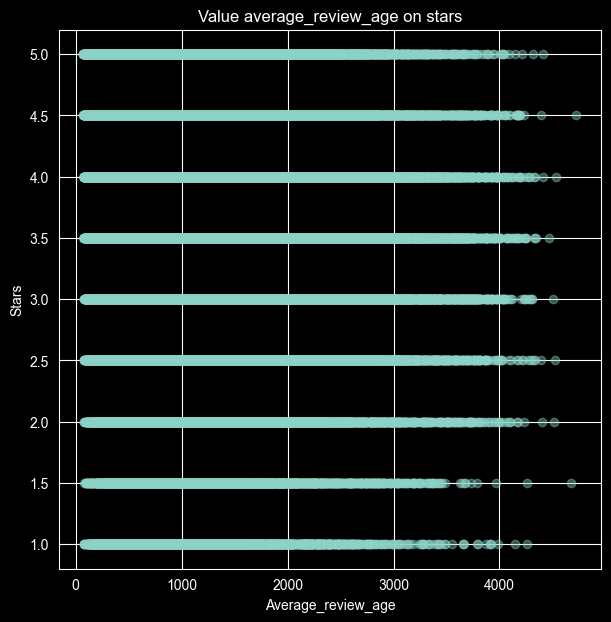

<Figure size 640x480 with 0 Axes>

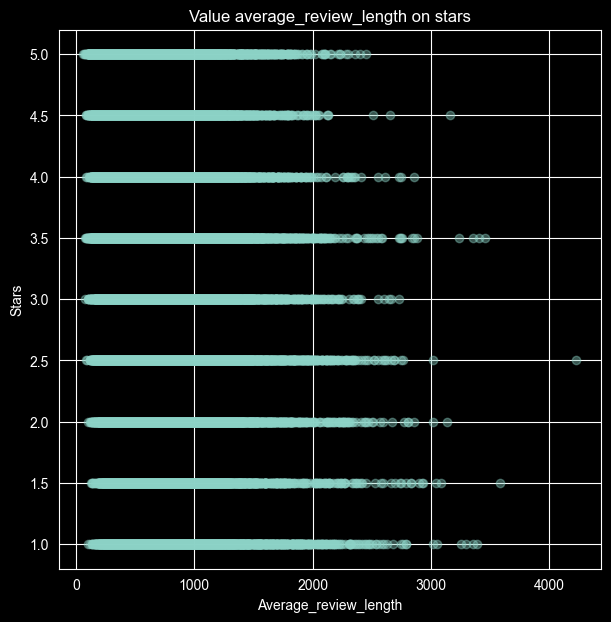

<Figure size 640x480 with 0 Axes>

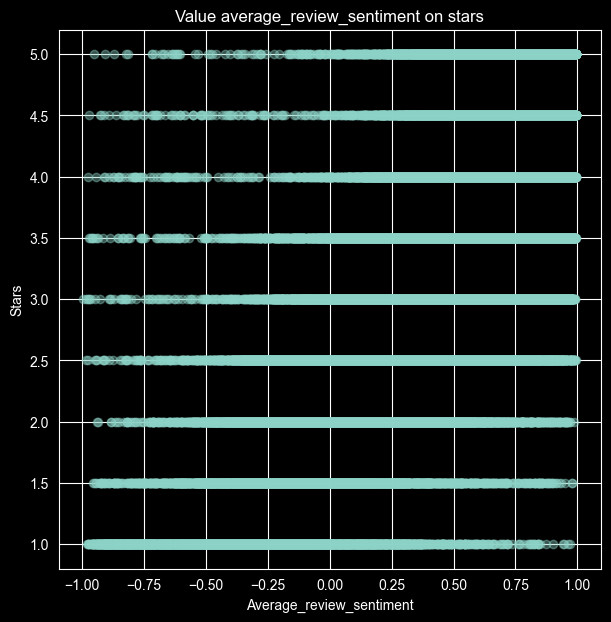

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(df['average_review_age'], df['stars'], alpha=0.4)
plt.xlabel('Average_review_age')
plt.ylabel('Stars')
plt.title('Value average_review_age on stars')
plt.show()
plt.clf()

plt.figure(figsize=(7, 7))
plt.scatter(df['average_review_length'], df['stars'], alpha=0.4)
plt.xlabel('Average_review_length')
plt.ylabel('Stars')
plt.title('Value average_review_length on stars')
plt.show()
plt.clf()

plt.figure(figsize=(7, 7))
plt.scatter(df['average_review_sentiment'], df['stars'], alpha=0.4)
plt.xlabel('Average_review_sentiment')
plt.ylabel('Stars')
plt.title('Value average_review_sentiment on stars')
plt.show()
plt.clf()

Создадим новый датафрейм с наиболее коррелирующими признаками с нашей целевой переменной

In [22]:
features = df[['average_review_length', 'average_review_age']]
ratings = df['stars']

Произведем разделение данных на тренеровочную и тестовую выборку

In [26]:
X_train, X_test, y_train, y_test = train_test_split(features, ratings, train_size=0.8, test_size=0.2, random_state=1)

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
print(f'R^2 на тренеровочной выборке: {train_score}')

test_score = model.score(X_test, y_test)
print(f'R^2 на тестовой выборке: {test_score}')

predict = model.predict(X_test)

R^2 на тренеровочной выборке: 0.08250309566544889
R^2 на тестовой выборке: 0.08083081210060561


Выведем кооэфициенты модели

In [37]:
sorted(list(zip(['average_review_length','average_review_age'],model.coef_)),key = lambda x: abs(x[1]),reverse=True)

[('average_review_length', np.float64(-0.0009977176852074558)),
 ('average_review_age', np.float64(-0.00011621626836366481))]

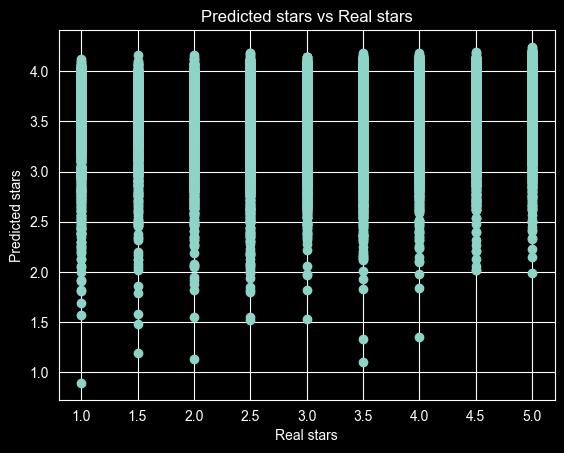

In [41]:
plt.scatter(y_test, predict)
plt.xlabel('Real stars')
plt.ylabel('Predicted stars')
plt.title('Predicted stars vs Real stars')
plt.show()

После построения первой модели на признаках `average_review_length` и `average_review_age` можно сделать вывод что они слабо влияют на определение рейтинга ресторана

Попробуем предсказать рейтинг на основе групп других признаков

In [46]:
binary_features = ['alcohol?','has_bike_parking','takes_credit_cards','good_for_kids','take_reservations','has_wifi']
sentiment = ['average_review_sentiment']

numeric_features = ['review_count','price_range','average_caption_length','number_pics','average_review_age','average_review_length','average_review_sentiment','number_funny_votes','number_cool_votes','number_useful_votes','average_tip_length','number_tips','average_number_friends','average_days_on_yelp','average_number_fans','average_review_count','average_number_years_elite','weekday_checkins','weekend_checkins']

all_features = binary_features + numeric_features

Создадим функцию в которой мы будем создавать модель, для более простого сравнения массивов признаков

In [44]:
def model_features(list_of_features):
    ratings = df['stars']
    features = df[list_of_features]

    X_train, X_test, y_train, y_test = train_test_split(features, ratings, test_size=0.2, random_state=1)

    if len(X_train) < 2:            # Проверка, не является ли массив признаков одномерным, если является, то преобразует в двумерный(столбец), так как линейная регрессия ожидает на вход двумерный массив
        X_train = np.array(X_train).reshape(-1, 1)
        X_test = np.array(X_test).reshape(-1, 1)

    model = LinearRegression()
    model.fit(X_train, y_train)

    print('Train Score:', model.score(X_train, y_train))
    print('Test Score:', model.score(X_test, y_test))

    print(sorted(list(zip(list_of_features, model.coef_)), key = lambda x: abs(x[1]), reverse=True))

    y_predicted = model.predict(X_test)

    plt.scatter(y_test,y_predicted)
    plt.xlabel('Yelp Rating')
    plt.ylabel('Predicted Yelp Rating')
    plt.ylim(1,5)
    plt.show()

Train Score: 0.012223180709591164
Test Score: 0.010119542202269294
[('has_bike_parking', np.float64(0.19003008208033756)), ('alcohol?', np.float64(-0.14549670708129372)), ('has_wifi', np.float64(-0.13187397577761079)), ('good_for_kids', np.float64(-0.08632485990335796)), ('takes_credit_cards', np.float64(0.07175536492192688)), ('take_reservations', np.float64(0.04526558530451027))]


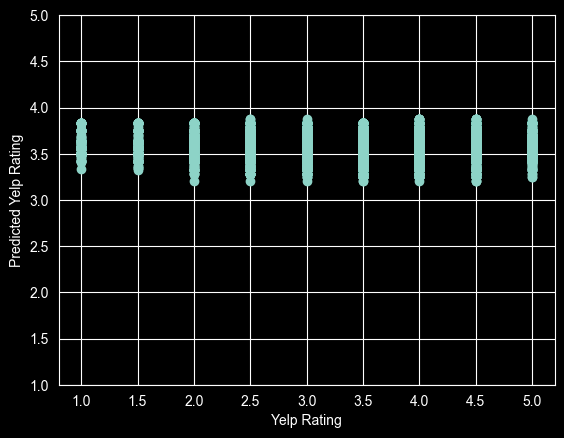

In [45]:
model_features(binary_features)

Train Score: 0.6118980950438655
Test Score: 0.6114021046919492
[('average_review_sentiment', np.float64(2.303390843374967))]


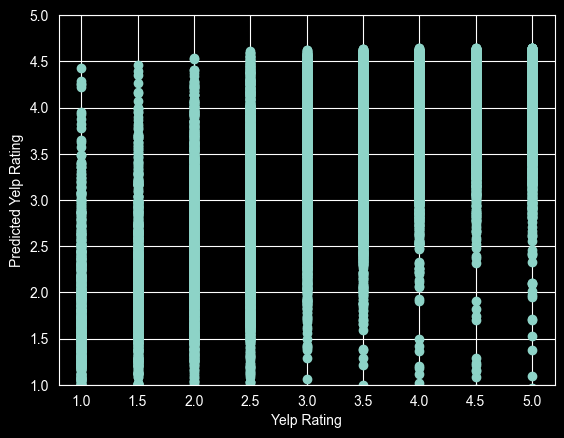

In [47]:
model_features(sentiment)

Train Score: 0.6734992593766658
Test Score: 0.6713318798120143
[('average_review_sentiment', np.float64(2.272107664209588)), ('price_range', np.float64(-0.0804608096270061)), ('average_number_years_elite', np.float64(-0.07190366288054284)), ('average_caption_length', np.float64(-0.0033470660077835925)), ('number_pics', np.float64(-0.0029565028128918356)), ('number_tips', np.float64(-0.0015953050789020019)), ('number_cool_votes', np.float64(0.0011468839227095225)), ('average_number_fans', np.float64(0.0010510602097475931)), ('average_review_length', np.float64(-0.0005813655692093265)), ('average_tip_length', np.float64(-0.0005322032063460391)), ('number_useful_votes', np.float64(-0.00023203784758681618)), ('average_review_count', np.float64(-0.00022431702895083535)), ('average_review_age', np.float64(-0.0001693060816508608)), ('average_days_on_yelp', np.float64(0.00012878025876716603)), ('weekday_checkins', np.float64(5.918580754471492e-05)), ('weekend_checkins', np.float64(-5.518176206

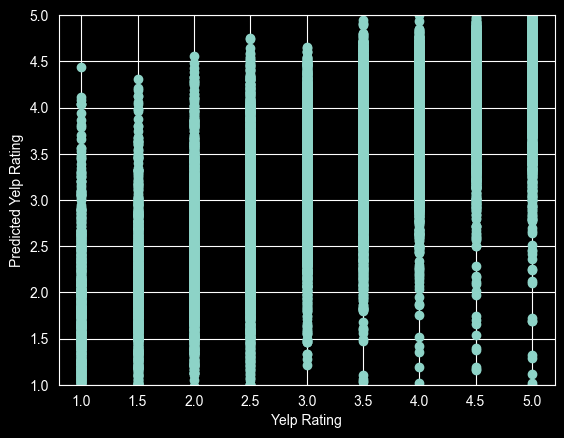

In [48]:
model_features(numeric_features)

Train Score: 0.6807828861895335
Test Score: 0.6782129045869248
[('average_review_sentiment', np.float64(2.2808456996623767)), ('alcohol?', np.float64(-0.1499149859346192)), ('has_wifi', np.float64(-0.12155382629260757)), ('good_for_kids', np.float64(-0.11807814422010336)), ('price_range', np.float64(-0.0648673015004198)), ('average_number_years_elite', np.float64(-0.06278939713895322)), ('has_bike_parking', np.float64(0.027296969912235076)), ('takes_credit_cards', np.float64(0.02445183785362551)), ('take_reservations', np.float64(0.014134559172960654)), ('number_pics', np.float64(-0.0013133612300802635)), ('average_number_fans', np.float64(0.0010267986822656474)), ('number_cool_votes', np.float64(0.0009723722734414041)), ('number_tips', np.float64(-0.0008546563320877053)), ('average_caption_length', np.float64(-0.0006472749798199224)), ('average_review_length', np.float64(-0.0005896257920272622)), ('average_tip_length', np.float64(-0.0004205217503408436)), ('number_useful_votes', np.fl

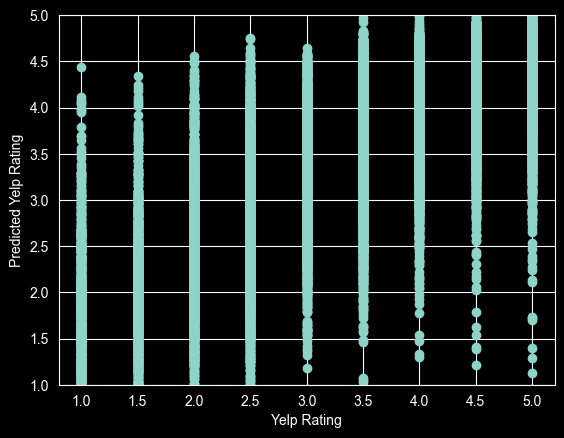

In [49]:
model_features(all_features)

Лучшей оказалась модель использующая в качестве массива признаков `all_features`, используем её для прогноза рейтинга нашего ресторана

Переобучим модель на новых признаках

In [50]:
features = df[all_features]
ratings = df['stars']
X_train, X_test, y_train, y_test = train_test_split(features, ratings, test_size = 0.2, random_state = 1)
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Выведем средние, минимальные и максимальные значения каждого признака, чтобы увидеть данные о других ресторанах и ввести данные о своем ресторане, если мы будем не знать что ввести, то можно ввести среднее значение признака

In [51]:
pd.DataFrame(list(zip(features.columns, features.describe().loc['mean'], features.describe().loc['min'], features.describe().loc['max'])), columns=['Feature', 'Mean', 'Min', 'Max'])

,Feature,Mean,Min,Max
0,alcohol?,0.140610,0.000000,1.000000
1,has_bike_parking,0.350692,0.000000,1.000000
2,takes_credit_cards,0.700243,0.000000,1.000000
3,good_for_kids,0.279029,0.000000,1.000000
4,take_reservations,0.106086,0.000000,1.000000
5,has_wifi,0.134968,0.000000,1.000000
6,review_count,31.797310,3.000000,7968.000000
7,price_range,1.035855,0.000000,4.000000
8,average_caption_length,2.831829,0.000000,140.000000
9,number_pics,1.489939,0.000000,1150.000000


In [54]:
my_restaurant_features = np.array([0,1,1,1,1,1,10,2,3,10,10,1200,0.9,3,6,5,50,3,50,1800,12,123,0.5,0,0]).reshape(1, -1)

In [55]:
model.predict(my_restaurant_features)

C:\Users\vorob\PycharmProjects\RestaurantsReveiw\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.03799004])

Оценка 4 вполне неплохо. Я реализовал получил данные, загрузил их, просмотрел их содержимое, собрал их в один датафрейм, очистил данные от пропусков и лишних колонок, обучил модель, посмотрел `score`, отобрал различные признаки, обучил несколько моделей линейной регрессии и выбрал лучший набор признаков, нашел рейтинг своего ресторана.